In [1]:
from google.colab import files
uploaded = files.upload()

Saving zomato.csv.zip to zomato.csv.zip


In [2]:
import zipfile

with zipfile.ZipFile("zomato.csv.zip", "r") as zip_ref:
    zip_ref.extractall()

print("File extracted successfully!")

File extracted successfully!


In [3]:
import os
os.listdir()

['.config', 'zomato.csv', 'zomato.csv.zip', 'sample_data']

In [4]:
import pandas as pd

df = pd.read_csv("zomato.csv")

In [5]:
df.head()

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memory usage: 5.6

In [7]:
df.isnull().sum()

,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [8]:
df.describe(include='all')

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [9]:
 import numpy as np

# Replace missing values
df["address"] = df["address"].fillna("Unknown")
df["name"] = df["name"].fillna("Unknown")
df["online_order"] = df["online_order"].fillna("Unknown")
df["book_table"] = df["book_table"].fillna("Unknown")
df["rate"] = df["rate"].fillna("0")
df["votes"] = df["votes"].fillna(0)
df["phone"] = df["phone"].fillna("Unknown")
df["location"] = df["location"].fillna("Unknown")
df["rest_type"] = df["rest_type"].fillna("Unknown")
df["dish_liked"] = df["dish_liked"].fillna("Not Mentioned")
df["cuisines"] = df["cuisines"].fillna("Unknown")
df["approx_cost(for two people)"] = df["approx_cost(for two people)"].fillna("0")
df["listed_in(type)"] = df["listed_in(type)"].fillna("Unknown")

print(df.isnull().sum())

address                        0
name                           0
online_order                   0
book_table                     0
rate                           0
votes                          0
phone                          0
location                       0
rest_type                      0
dish_liked                     0
cuisines                       0
approx_cost(for two people)    0
listed_in(type)                0
dtype: int64


In [10]:
df["rate"] = df["rate"].astype(str)

df["rate"] = df["rate"].str.replace("/5","",regex=False)
df["rate"] = df["rate"].replace(["NEW","-"], np.nan)

df["rate"] = pd.to_numeric(df["rate"], errors="coerce")

df["rate"] = df["rate"].fillna(df["rate"].median())

df["rate"].head()

,rate
0,4.1
1,4.1
2,3.8
3,3.7
4,3.8


In [11]:
df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .astype(str)
    .str.replace(",","",regex=False)
)

df["approx_cost(for two people)"] = pd.to_numeric(
    df["approx_cost(for two people)"],
    errors="coerce"
)

df["approx_cost(for two people)"] = (
    df["approx_cost(for two people)"]
    .fillna(df["approx_cost(for two people)"].median())
)

In [12]:
print("Total Restaurants:", df["name"].nunique())
print("Total Locations:", df["location"].nunique())
print("Total Cuisine Types:", df["cuisines"].nunique())
print("Average Rating:", round(df["rate"].mean(),2))

Total Restaurants: 11915
Total Locations: 2921
Total Cuisine Types: 5554
Average Rating: 3.17


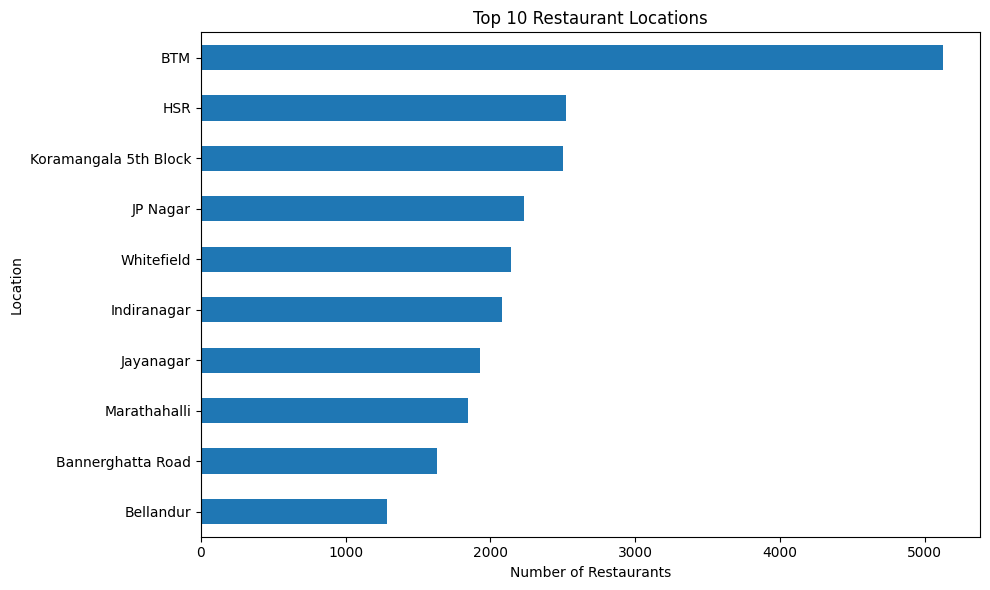

In [17]:
 import matplotlib.pyplot as plt

top_locations = df['location'].value_counts().head(10)

plt.figure(figsize=(10,6))
top_locations.sort_values().plot(kind='barh')

plt.title('Top 10 Restaurant Locations')
plt.xlabel('Number of Restaurants')
plt.ylabel('Location')

plt.tight_layout()
plt.show()

In [18]:
 print(df['online_order'].value_counts().head(20))

online_order
Yes                                                                                                                                                                                                                                                    30444
No                                                                                                                                                                                                                                                     21273
 ('Rated 4.0'                                                                                                                                                                                                                                            493
 ('Rated 5.0'                                                                                                                                                                                                                       

In [19]:
df['online_order'] = df['online_order'].astype(str)

df['online_order'] = df['online_order'].replace({
    'Yes':'Yes',
    'No':'No'
})

online_data = df[df['online_order'].isin(['Yes','No'])]

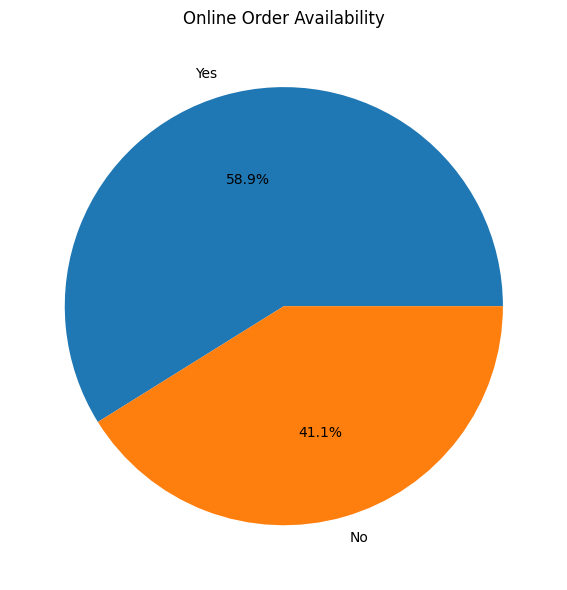

In [20]:
plt.figure(figsize=(6,6))

online_data['online_order'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Online Order Availability')

plt.ylabel('')

plt.tight_layout()
plt.show()

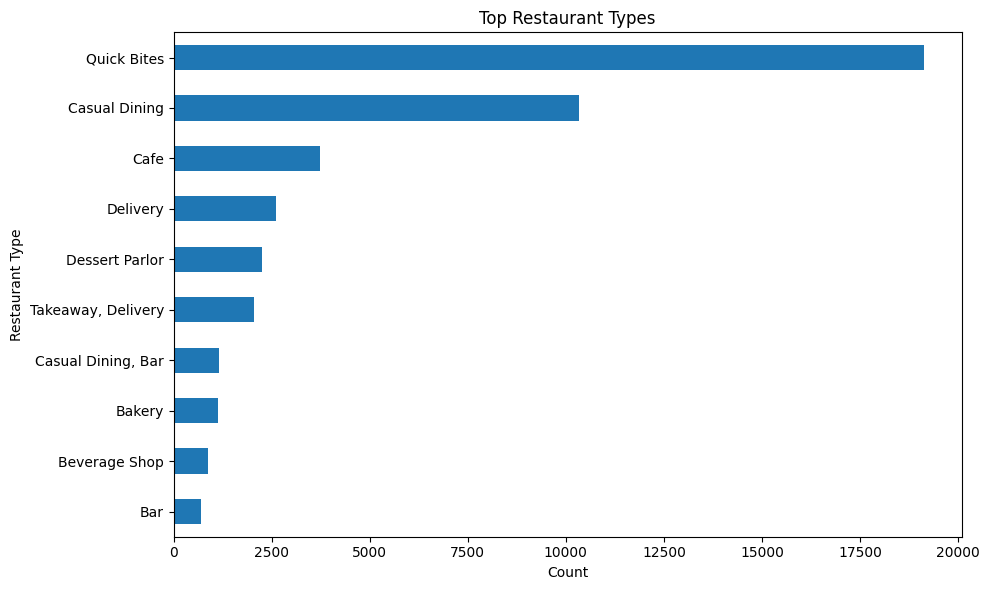

In [21]:
top_rest = df['rest_type'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_rest.sort_values().plot(kind='barh')

plt.title('Top Restaurant Types')
plt.xlabel('Count')
plt.ylabel('Restaurant Type')

plt.tight_layout()
plt.show()

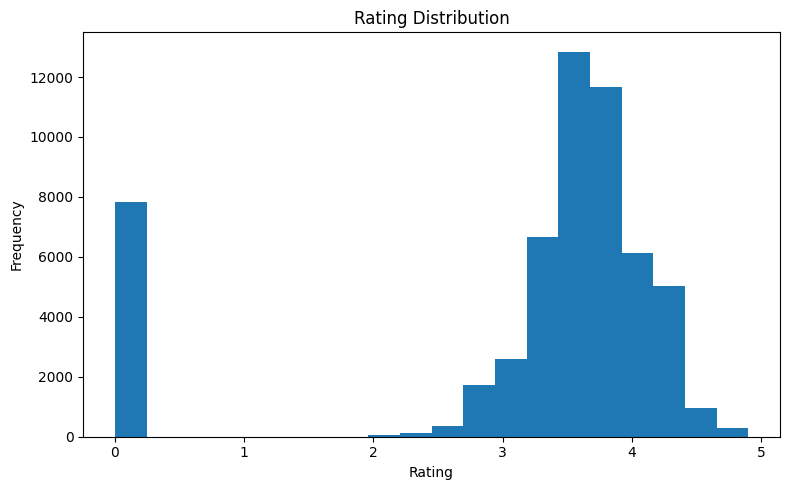

In [22]:
plt.figure(figsize=(8,5))

df['rate'].plot(
    kind='hist',
    bins=20
)

plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

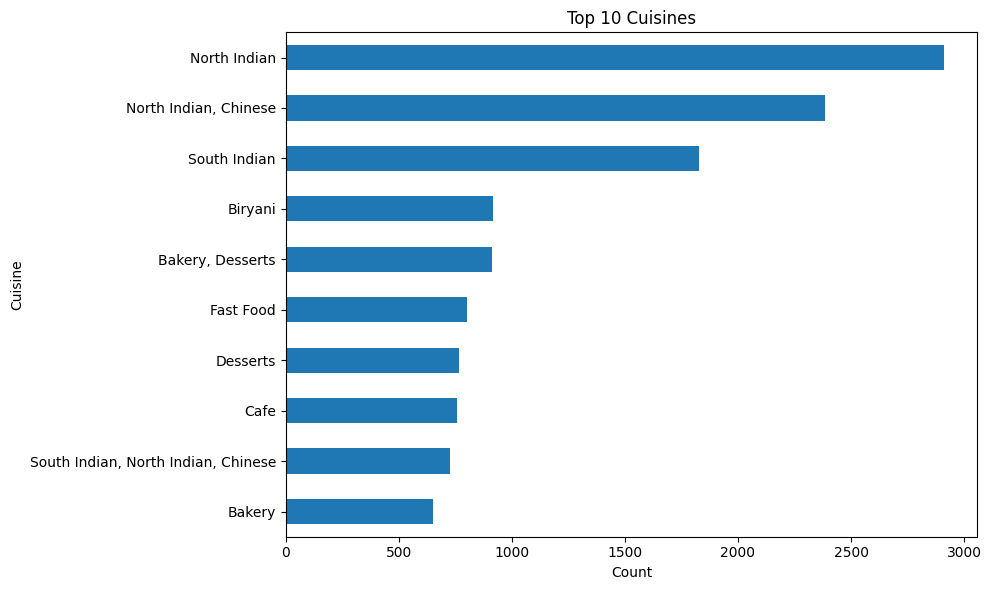

In [23]:
top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize=(10,6))

top_cuisines.sort_values().plot(kind='barh')

plt.title('Top 10 Cuisines')
plt.xlabel('Count')
plt.ylabel('Cuisine')

plt.tight_layout()
plt.show()

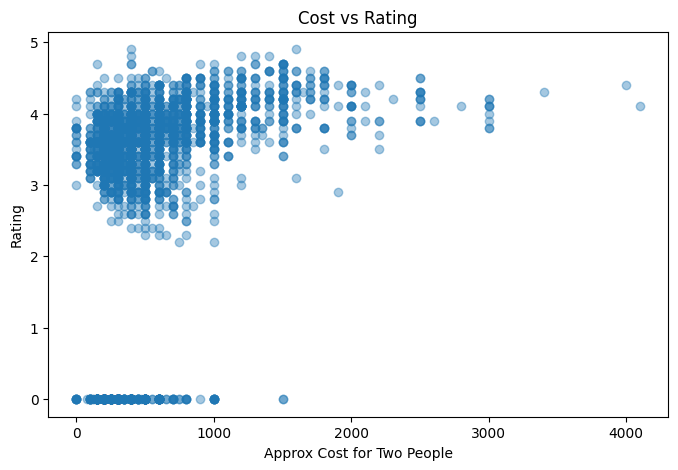

In [32]:
sample_df = df.sample(n=3000, random_state=42)

plt.figure(figsize=(8,5))

plt.scatter(
    sample_df['approx_cost(for two people)'],
    sample_df['rate'],
    alpha=0.4
)

plt.title('Cost vs Rating')
plt.xlabel('Approx Cost for Two People')
plt.ylabel('Rating')

plt.show()

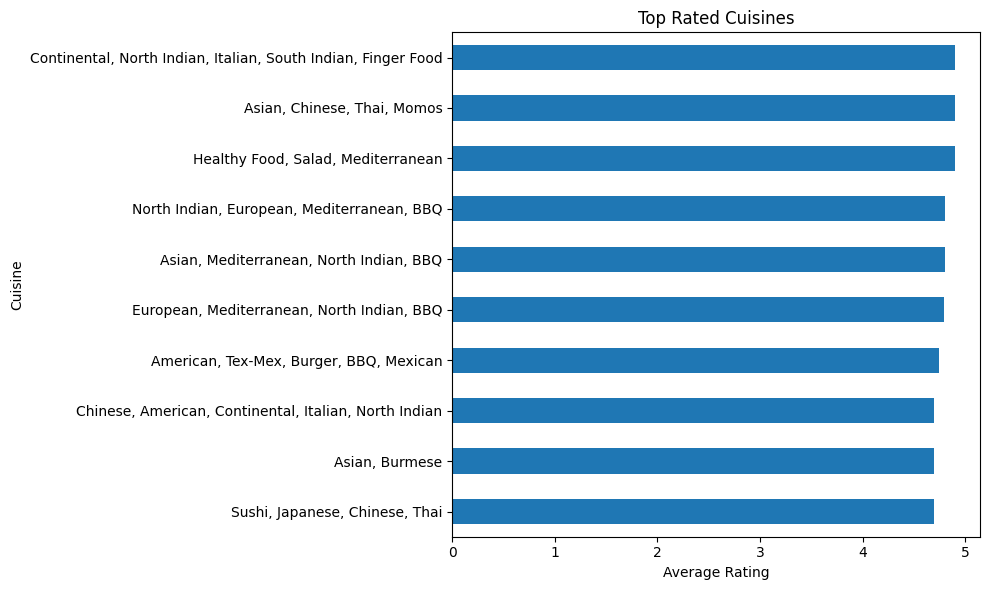

In [24]:
avg_rating = (
    df.groupby('cuisines')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))

avg_rating.sort_values().plot(kind='barh')

plt.title('Top Rated Cuisines')
plt.xlabel('Average Rating')
plt.ylabel('Cuisine')

plt.tight_layout()
plt.show()

In [25]:
print(df['online_order'].value_counts().head(20))

online_order
Yes                                                                                                                                                                                                                                                    30444
No                                                                                                                                                                                                                                                     21273
 ('Rated 4.0'                                                                                                                                                                                                                                            493
 ('Rated 5.0'                                                                                                                                                                                                                       

In [26]:
# Keep only valid Yes/No values
df = df[df['online_order'].isin(['Yes', 'No'])]

print(df['online_order'].value_counts())

online_order
Yes    30444
No     21273
Name: count, dtype: int64


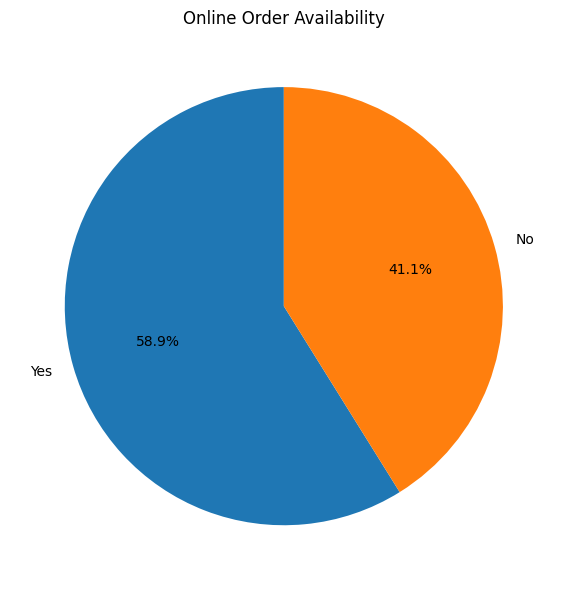

In [27]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df['online_order'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Online Order Availability')

plt.ylabel('')

plt.tight_layout()

plt.show()

In [28]:
print("Total Restaurants:", df["name"].nunique())
print("Total Locations:", df["location"].nunique())
print("Total Cuisine Types:", df["cuisines"].nunique())
print("Average Rating:", round(df["rate"].mean(),2))

Total Restaurants: 8792
Total Locations: 94
Total Cuisine Types: 2724
Average Rating: 3.14


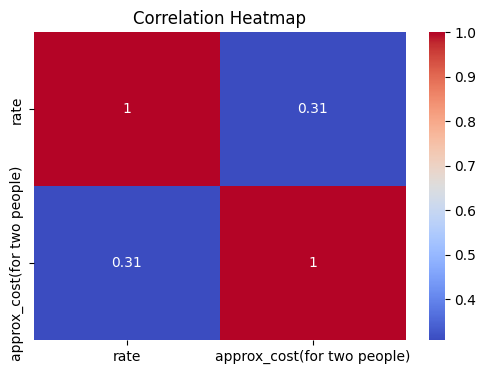

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_df = df[['rate','approx_cost(for two people)']]

plt.figure(figsize=(6,4))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

In [30]:
top_locations_rating = (
    df.groupby('location')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_locations_rating)

location
St. Marks Road           3.914489
Lavelle Road             3.895274
Church Street            3.856063
Rajarajeshwari Nagar     3.850000
Sankey Road              3.818519
Langford Town            3.807407
Koramangala 5th Block    3.799002
Cunningham Road          3.773931
Race Course Road         3.725180
Kengeri                  3.722222
Name: rate, dtype: float64


In [31]:
top_cuisines_rating = (
    df.groupby('cuisines')['rate']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print(top_cuisines_rating)

cuisines
Continental, North Indian, Italian, South Indian, Finger Food    4.900000
Asian, Chinese, Thai, Momos                                      4.900000
Healthy Food, Salad, Mediterranean                               4.900000
North Indian, European, Mediterranean, BBQ                       4.800000
Asian, Mediterranean, North Indian, BBQ                          4.800000
European, Mediterranean, North Indian, BBQ                       4.789474
American, Tex-Mex, Burger, BBQ, Mexican                          4.750000
Continental, European, BBQ, Chinese, Asian                       4.700000
Chinese, American, Continental, Italian, North Indian            4.700000
Asian, Burmese                                                   4.700000
Name: rate, dtype: float64
